In [36]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


## 1. Load and inspect the head and shape

In [37]:
df = pd.read_csv('CustomerBehavior.csv')
display(df.head())
print('Shape:', df.shape)
df.info()


,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,"1,120.20",14,4.60,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.10,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.40,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,"1,480.30",19,4.70,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.00,True,55,Unsatisfied


Shape: (350, 11)
<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    str    
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    str    
 4   Membership Type           350 non-null    str    
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    str    
dtypes: bool(1), float64(2), int64(4), str(4)
memory usage: 27.8 KB


## 2. Data-quality checks
checking if there's any missing columns or duplicated customers or customer ids and dropping those fr

In [38]:
display(df.isna().sum().rename('missing').to_frame())
print('Duplicate rows:', df.duplicated().sum())
print('Duplicate customer IDs:', df['Customer ID'].duplicated().sum())
mode_satisfaction = df["Satisfaction Level"].mode()[0]

df["Satisfaction Level"] = df["Satisfaction Level"].fillna(
    mode_satisfaction
)

print("Missing values after treatment:")
print(df["Satisfaction Level"].isnull().sum())
display(df.isna().sum().rename('missing').to_frame())


,missing
Customer ID,0
Gender,0
Age,0
City,0
Membership Type,0
Total Spend,0
Items Purchased,0
Average Rating,0
Discount Applied,0
Days Since Last Purchase,0


Duplicate rows: 0
Duplicate customer IDs: 0
Missing values after treatment:
0


,missing
Customer ID,0
Gender,0
Age,0
City,0
Membership Type,0
Total Spend,0
Items Purchased,0
Average Rating,0
Discount Applied,0
Days Since Last Purchase,0


## 3. Clean and engineer variables

In [40]:
numeric_cols = ['Age','Total Spend','Items Purchased','Average Rating','Days Since Last Purchase']
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df['Discount Applied'] = df['Discount Applied'].astype(str).str.upper().eq('TRUE')
df['Spend per Item'] = df['Total Spend'] / df['Items Purchased']
df['Age Group'] = pd.cut(df['Age'], [0,29,39,49,100], labels=['18-29','30-39','40-49','50+'])
df['Recency Group'] = pd.cut(df['Days Since Last Purchase'], [-1,14,30,45,np.inf], labels=['0-14 days','15-30 days','31-45 days','46+ days'])
df['High Value'] = df['Total Spend'] >= df['Total Spend'].quantile(.75)




## 4. Descriptive statistics

In [41]:
display(df[numeric_cols + ['Spend per Item']].describe().T)
print('Total spend:', df['Total Spend'].sum())
display(df['Satisfaction Level'].value_counts(dropna=False).rename('customers').to_frame())
categorical_columns = [
    "Gender",
    "City",
    "Membership Type",
    "Discount Applied",
    "Satisfaction Level"
]

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts())


,count,mean,std,min,25%,50%,75%,max
Age,350.00,33.60,4.87,26.00,30.00,32.50,37.00,43.00
Total Spend,350.00,845.38,362.06,410.80,502.00,775.20,"1,160.60","1,520.10"
Items Purchased,350.00,12.60,4.16,7.00,9.00,12.00,15.00,21.00
Average Rating,350.00,4.02,0.58,3.00,3.50,4.10,4.50,4.90
Days Since Last Purchase,350.00,26.59,13.44,9.00,15.00,23.00,38.00,63.00
Spend per Item,350.00,65.23,9.00,49.52,57.37,67.03,73.03,83.59


Total spend: 295883.6


,customers
Satisfaction Level,
Satisfied,127
Unsatisfied,116
Neutral,107



--- Gender ---
Gender
Female    175
Male      175
Name: count, dtype: int64

--- City ---
City
New York         59
Los Angeles      59
Chicago          58
San Francisco    58
Miami            58
Houston          58
Name: count, dtype: int64

--- Membership Type ---
Membership Type
Gold      117
Silver    117
Bronze    116
Name: count, dtype: int64

--- Discount Applied ---
Discount Applied
True     175
False    175
Name: count, dtype: int64

--- Satisfaction Level ---
Satisfaction Level
Satisfied      127
Unsatisfied    116
Neutral        107
Name: count, dtype: int64


## 5. Membership and city summaries

In [42]:
membership = df.groupby('Membership Type', observed=True).agg(
    Customers=('Customer ID','count'), Total_Revenue=('Total Spend','sum'),
    Avg_Spend=('Total Spend','mean'), Median_Spend=('Total Spend','median'),
    Avg_Items=('Items Purchased','mean'), Avg_Rating=('Average Rating','mean'),
    Avg_Recency=('Days Since Last Purchase','mean'),
    Satisfaction_Rate=('Satisfaction Level', lambda s: (s == 'Satisfied').mean()))
display(membership)
city = df.groupby('City').agg(Customers=('Customer ID','count'), Avg_Spend=('Total Spend','mean'), Avg_Rating=('Average Rating','mean'), Avg_Recency=('Days Since Last Purchase','mean'), Unsatisfied_Rate=('Satisfaction Level', lambda s: (s == 'Unsatisfied').mean())).sort_values('Avg_Spend', ascending=False)
display(city)


,Customers,Total_Revenue,Avg_Spend,Median_Spend,Avg_Items,Avg_Rating,Avg_Recency,Satisfaction_Rate
Membership Type,,,,,,,,
Bronze,116,"54,913.10",473.39,475.25,8.49,3.32,31.61,0.02
Gold,117,"153,403.90","1,311.14","1,210.60",17.62,4.68,17.94,1.00
Silver,117,"87,566.60",748.43,770.20,11.66,4.05,30.26,0.07


,Customers,Avg_Spend,Avg_Rating,Avg_Recency,Unsatisfied_Rate
City,,,,,
San Francisco,58,"1,459.77",4.81,11.17,0.00
New York,59,"1,165.04",4.54,24.59,0.00
Los Angeles,59,805.49,4.17,15.27,0.00
Miami,58,690.39,3.93,45.50,1.00
Chicago,58,499.88,3.46,40.47,1.00
Houston,58,446.89,3.19,22.76,0.00


## 6. Main figures

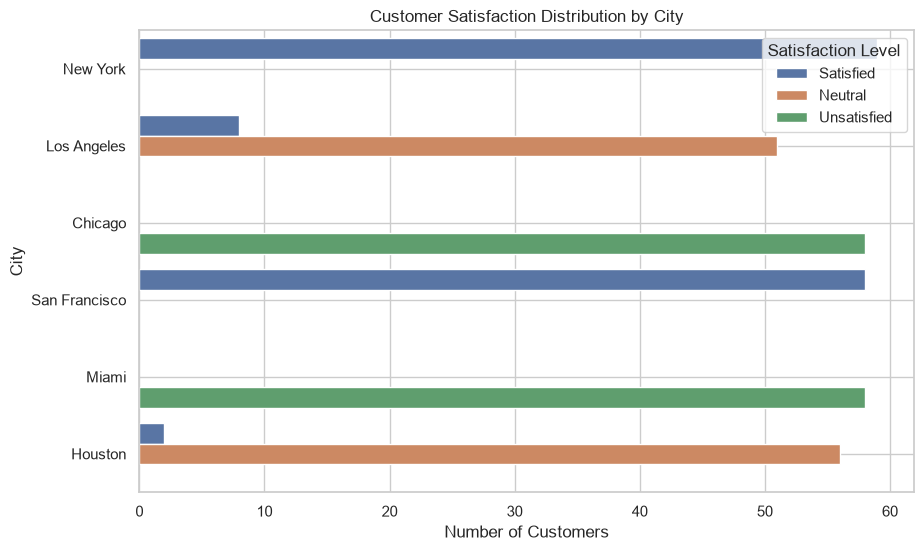

In [ ]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="City",
    hue="Satisfaction Level",
    order=df["City"].value_counts().index
)

plt.title("Customer Satisfaction Distribution by City")
plt.xlabel("Number of Customers")
plt.ylabel("City")
plt.grid(axis="y")
plt.savefig('CountPlot-City-Satisfaction.png', dpi=200, bbox_inches='tight')
plt.show()

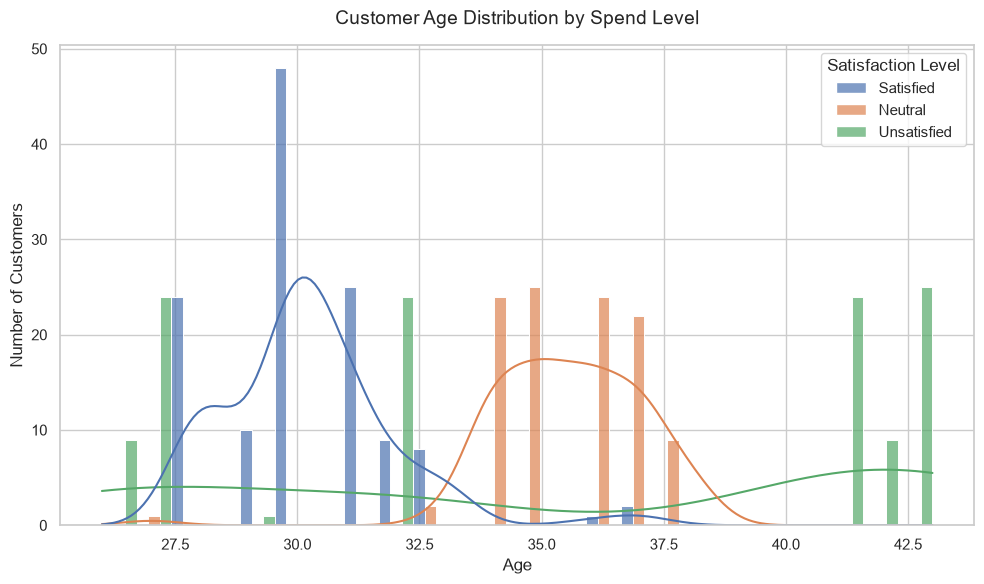

In [91]:
plt.figure(figsize=(10, 6))

# 1D Histogram focusing strictly on Age
sns.histplot(
    data=df,
    x="Age",
    hue="Satisfaction Level",
    bins=24,             # Increased from 5 for a smoother distribution overview
    kde=True,            # Correctly works on 1D histograms now
    multiple="dodge",    # Layer categories cleanly ('stack', 'dodge', or 'layer')
    alpha=0.7
)

# Labeling matching the data structure
plt.title("Customer Age Distribution by Spend Level", fontsize=14, pad=15)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.savefig('HistPlot-Age-Satisfaction.png', dpi=200, bbox_inches='tight')
plt.tight_layout()
plt.show()

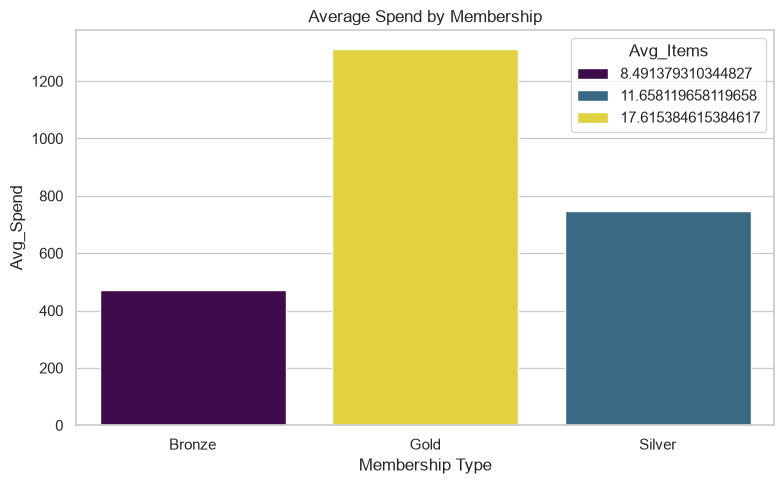

In [94]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=membership.reset_index(),
    x='Membership Type',
    y='Avg_Spend',
    hue="Avg_Items",
    legend=True,
    palette='viridis'
)
plt.title('Average Spend by Membership')
plt.tight_layout()
plt.savefig('avg_spend_Items_by_membership.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
box plot 

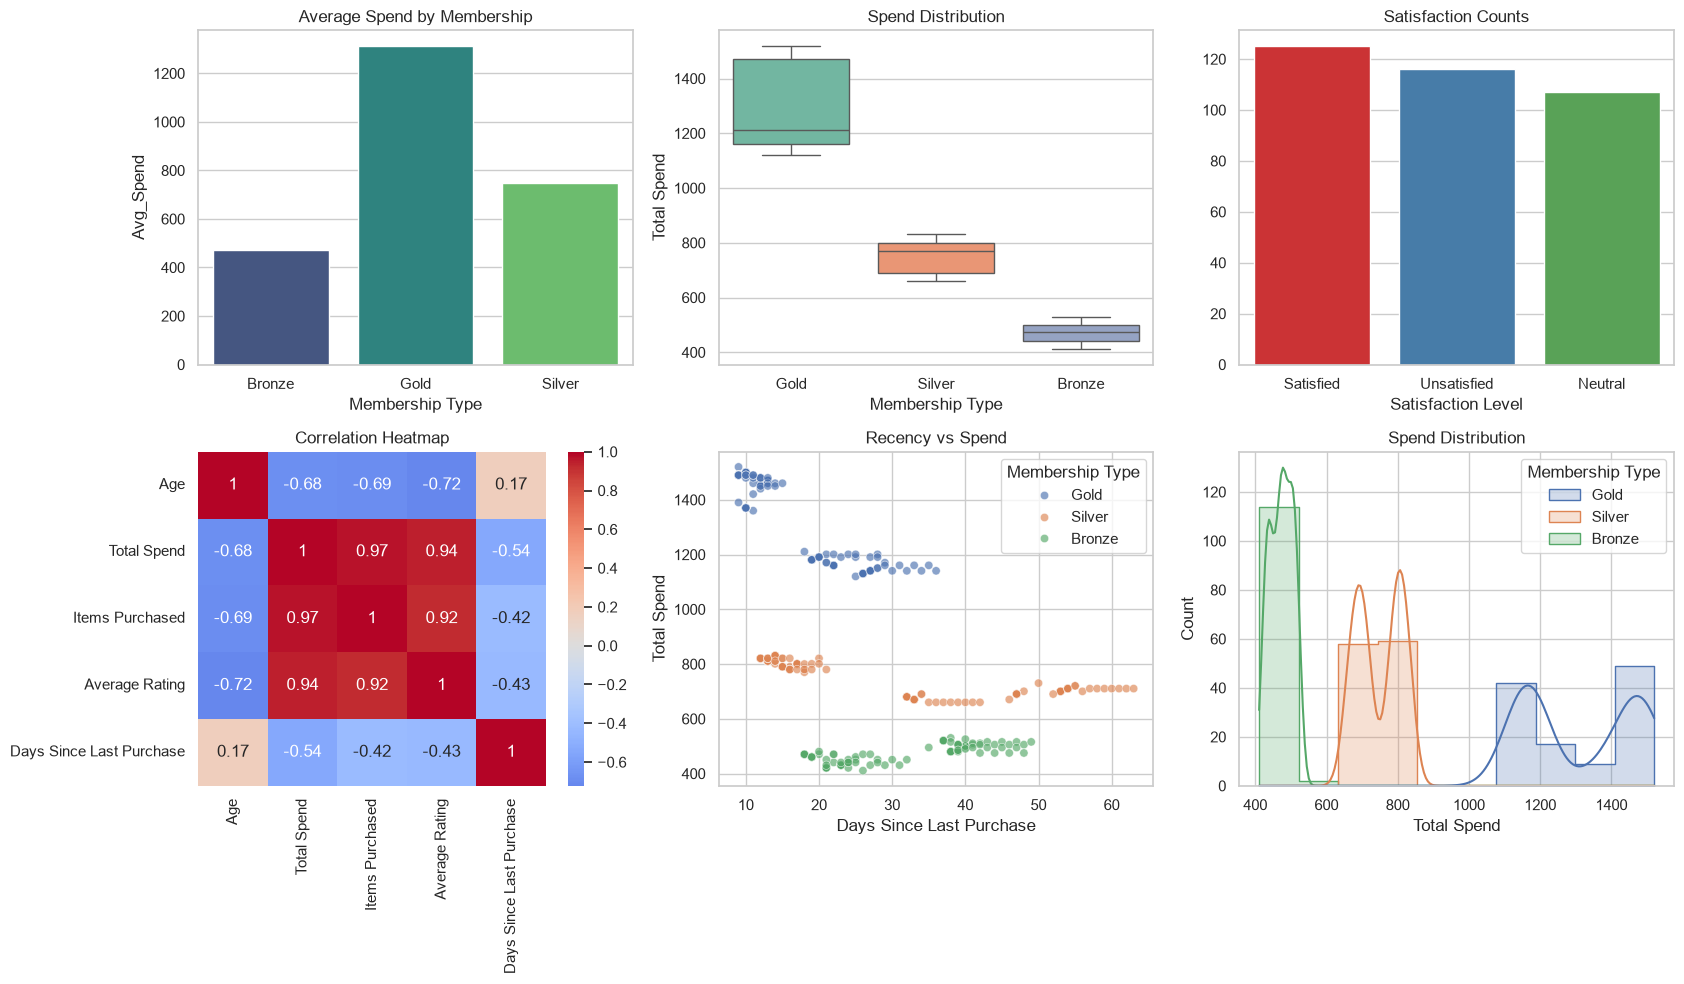

In [19]:
fig, ax = plt.subplots(2,3,figsize=(17,10))
sns.barplot(data=membership.reset_index(), x='Membership Type', y='Avg_Spend', hue='Membership Type', legend=False, palette='viridis', ax=ax[0,0]); ax[0,0].set_title('Average Spend by Membership')
sns.boxplot(data=df, x='Membership Type', y='Total Spend', hue='Membership Type', legend=False, palette='Set2', ax=ax[0,1]); ax[0,1].set_title('Spend Distribution')
sat=df['Satisfaction Level'].value_counts(dropna=False); sns.barplot(x=sat.index.astype(str), y=sat.values, hue=sat.index.astype(str), legend=False, palette='Set1', ax=ax[0,2]); ax[0,2].set_title('Satisfaction Counts')
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, ax=ax[1,0]); ax[1,0].set_title('Correlation Heatmap')
sns.scatterplot(data=df, x='Days Since Last Purchase', y='Total Spend', hue='Membership Type', alpha=.65, ax=ax[1,1]); ax[1,1].set_title('Recency vs Spend')
sns.histplot(data=df, x='Total Spend', hue='Membership Type', kde=True, element='step', ax=ax[1,2]); ax[1,2].set_title('Spend Distribution')
plt.tight_layout(); plt.savefig('core_customer_behavior_figures.png', dpi=200, bbox_inches='tight'); plt.show()


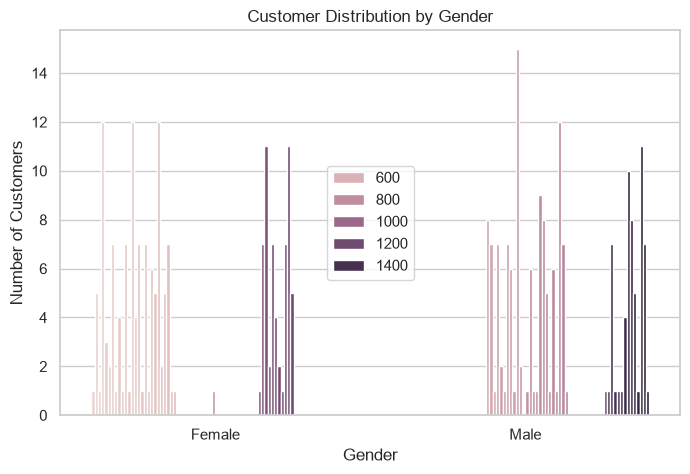

In [43]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Gender",
    hue="Total Spend",
    legend=True
)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.legend(loc="center")
plt.show()

## 7. Hidden-pattern figures

Satisfaction Level,Neutral,Satisfied,Unsatisfied
Membership Type,,,
Bronze,49.10,0.00,50.90
Gold,0.00,100.00,0.00
Silver,43.60,6.80,49.60


Recency Group,0–14 days,15–30 days,31–45 days,46+ days
Membership Type,,,,
Bronze,0.00,48.30,45.70,6.00
Gold,48.70,46.20,5.10,0.00
Silver,21.40,29.10,20.50,29.10


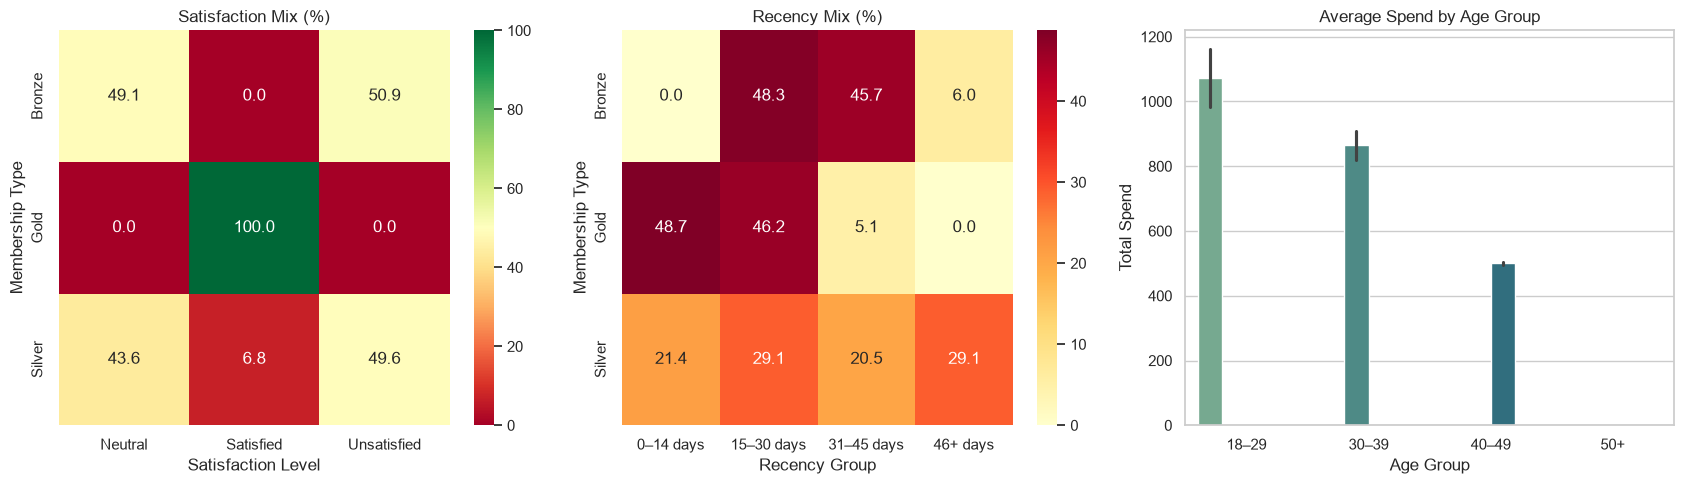

In [20]:
sat_mix = pd.crosstab(df['Membership Type'], df['Satisfaction Level'], normalize='index')*100
recency_mix = pd.crosstab(df['Membership Type'], df['Recency Group'], normalize='index')*100
display(sat_mix.round(1)); display(recency_mix.round(1))
fig, ax = plt.subplots(1,3,figsize=(17,5))
sns.heatmap(sat_mix, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax[0]); ax[0].set_title('Satisfaction Mix (%)')
sns.heatmap(recency_mix, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax[1]); ax[1].set_title('Recency Mix (%)')
sns.barplot(data=df, x='Age Group', y='Total Spend', hue='Age Group', legend=False, palette='crest', ax=ax[2]); ax[2].set_title('Average Spend by Age Group')
plt.tight_layout(); plt.savefig('hidden_pattern_figures.png', dpi=200, bbox_inches='tight'); plt.show()


## 8. Statistical comparisons without SciPy

In [21]:
# One-way ANOVA components for spend across membership tiers
groups=[g['Total Spend'].dropna().to_numpy() for _,g in df.groupby('Membership Type', observed=True)]
all_values=np.concatenate(groups); grand=all_values.mean()
ss_between=sum(len(g)*(g.mean()-grand)**2 for g in groups)
ss_within=sum(((g-g.mean())**2).sum() for g in groups)
dfb=len(groups)-1; dfw=len(all_values)-len(groups)
F=(ss_between/dfb)/(ss_within/dfw)
print(f'ANOVA F={F:.2f}, degrees of freedom=({dfb},{dfw})')

# Spearman rho via pandas ranks and NumPy correlation
for x in ['Items Purchased','Average Rating','Days Since Last Purchase','Age']:
    z=df[[x,'Total Spend']].dropna()
    rho=np.corrcoef(z[x].rank().to_numpy(), z['Total Spend'].rank().to_numpy())[0,1]
    print(f'Spearman {x} vs spend: rho={rho:.3f}')

# Permutation test for discount vs no-discount average spend
x=df.loc[df['Discount Applied'],'Total Spend'].dropna().to_numpy(); y=df.loc[~df['Discount Applied'],'Total Spend'].dropna().to_numpy()
observed=x.mean()-y.mean(); pooled=np.concatenate([x,y]); rng=np.random.default_rng(42); perm=[]
for i in range(5000):
    s=rng.permutation(pooled); perm.append(s[:len(x)].mean()-s[len(x):].mean())
p=np.mean(np.abs(perm)>=abs(observed))
print(f'Discount average-spend difference=${observed:,.2f}; permutation p≈{p:.4f}')


ANOVA F=2294.49, degrees of freedom=(2,347)
Spearman Items Purchased vs spend: rho=0.971
Spearman Average Rating vs spend: rho=0.965
Spearman Days Since Last Purchase vs spend: rho=-0.574
Spearman Age vs spend: rho=-0.706
Discount average-spend difference=$-116.22; permutation p≈0.0026


## 9. Outliers and repeated profiles

In [22]:
rows=[]
for c in numeric_cols:
    q1,q3=df[c].quantile([.25,.75]); iqr=q3-q1
    lo,hi=q1-1.5*iqr,q3+1.5*iqr
    rows.append([c,q1,q3,lo,hi,((df[c]<lo)|(df[c]>hi)).sum()])
display(pd.DataFrame(rows,columns=['Variable','Q1','Q3','Lower fence','Upper fence','Outlier count']))
profile_counts=df.drop(columns='Customer ID').value_counts()
print('Repeated behavioral profiles:', (profile_counts>1).sum())
display(profile_counts.head(10).to_frame('count'))


,Variable,Q1,Q3,Lower fence,Upper fence,Outlier count
0,Age,30.00,37.00,19.50,47.50,0
1,Total Spend,502.00,"1,160.60",-485.90,"2,148.50",0
2,Items Purchased,9.00,15.00,0.00,24.00,0
3,Average Rating,3.50,4.50,2.00,6.00,0
4,Days Since Last Purchase,15.00,38.00,-19.50,72.50,0


Repeated behavioral profiles: 41


count
Gender Age City          Membership Type Total Spend Items Purchased Average Rating Discount Applied Days Since Last Purchase Satisfaction Level Spend per Item Age Group Recency Group High Value       
Male   30  San Francisco Gold            1,470.50    20              4.80           False            13                       Satisfied          73.53          30–39     0–14 days     True            8
       27  Miami         Silver          710.40      13              4.10           True             54                       Unsatisfied        54.65          18–29     46+ days      False           8
Female 37  Houston       Bronze          430.80      7               3.40           False            23                       Neutral            61.54          30–39     15–30 days    False           8
Male   34  Los Angeles   Silver          790.20      11              4.00           False            15                       Neutral            71.84          30–39     15–30 days    False           8
Female 41  Chicago       Bronze          485.25      9               3.60           True             39                       Unsatisfied        53.92          40–49     31–45 days    False           7
Male   28  San Francisco Gold            1,500.10    21              4.90           False            10                       Satisfied          71.43          18–29     0–14 days     True            7
       32  Miami         Silver          670.30      10              3.80           True             33                       Unsatisfied        67.03          30–39     31–45 days    False           7
Female 36  Houston       Bronze          460.50      8               3.10           False            19                       Neutral            57.56          30–39     15–30 days    False           7
       30  New York      Gold            1,190.80    16              4.50           True             20                       Satisfied          74.42          30–39     15–30 days    True            7
Male   33  Los Angeles   Silver          830.75      13              4.20           False            14                       Satisfied          63.90          30–39     0–14 days     False           7

## 10. Conclusions and limitations

In [23]:
print('Gold is the highest-value tier; compare its spend, rating, items, and recency with Bronze above.')
print('Spend is strongly associated with items purchased and rating; check the heatmap and Spearman values.')
print('Later recency is associated with lower spend, supporting targeted win-back analysis.')
print('These are observational relationships, not causal effects.')
print('No transaction date is available, so time-series trends cannot be estimated.')
print('Validate the three missing satisfaction labels and investigate repeated profiles before production reporting.')


Gold is the highest-value tier; compare its spend, rating, items, and recency with Bronze above.
Spend is strongly associated with items purchased and rating; check the heatmap and Spearman values.
Later recency is associated with lower spend, supporting targeted win-back analysis.
These are observational relationships, not causal effects.
No transaction date is available, so time-series trends cannot be estimated.
Validate the three missing satisfaction labels and investigate repeated profiles before production reporting.
